In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

import koreanize_matplotlib
import warnings
warnings.filterwarnings('ignore')

In [17]:
df = pd.read_csv('../Data/당뇨_전처리.csv')
df

,임신횟수,혈당,혈압,피부두께,인슐린,BMI,가족력지표,나이,당뇨
0,6,148.0,72.0,35.0,159.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,95.0,26.6,0.351,31,0
2,8,183.0,64.0,32.0,159.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
712,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
713,2,122.0,70.0,27.0,95.0,36.8,0.340,27,0
714,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
715,1,126.0,60.0,32.0,159.0,30.1,0.349,47,1


In [18]:
# 모든 지표를 사용
df = df[['BMI','혈당','나이','임신횟수','혈압','가족력지표','피부두께','인슐린','당뇨']]

In [19]:
# train과 test로 분리

data = df.iloc[:,:-1]
target = df.iloc[:,-1]

train_data, test_data, train_target, test_target = train_test_split(
    data,
    target,
    random_state=42,
    test_size= 0.2,
    stratify=df.iloc[:,-1]
)

# 가족력지표와 인슐린의 규모가 다르므로 정규화 진행

ss = StandardScaler()
ss.fit(train_data)
train_scaled = ss.transform(train_data)
test_scaled = ss.transform(test_data)


In [20]:
print(train_data.shape)
print(test_data.shape)
print(train_target.shape)
print(test_target.shape)

(573, 8)
(144, 8)
(573,)
(144,)


In [21]:
x_train_data, x_valid_data, y_train_target, y_valid_target = train_test_split(
    train_scaled,
    train_target,
    random_state=42,
    test_size= 0.2,
    stratify=train_target
)

In [22]:
train_scaled

array([[ 1.68238713,  1.09820526,  0.27837348, ...,  0.13210762,
         0.4298286 ,  1.73431738],
       [ 1.00819685,  0.23701515,  1.40533219, ..., -0.39039838,
         0.91204454, -0.2580937 ],
       [-1.10630903, -0.41748933, -0.93527437, ..., -1.04431308,
        -1.01681921, -0.51202844],
       ...,
       [-0.23292616,  1.58047172,  1.40533219, ..., -0.53745097,
         0.4298286 ,  0.73811184],
       [ 0.91626182,  0.92596723, -0.41513958, ..., -0.43733006,
         0.4298286 ,  0.73811184],
       [ 1.51383956,  1.09820526,  0.45175174, ...,  0.83921155,
         1.39426048,  2.92585734]])

In [23]:
print(x_train_data.shape)
print(x_valid_data.shape)
print(y_train_target.shape)
print(y_valid_target.shape)

(458, 8)
(115, 8)
(458,)
(115,)


---
### RF

In [24]:
estimator_range = range(5,201,5)
cv_scores = []
for r in estimator_range:
    rf = RandomForestClassifier(n_estimators=r, n_jobs=-1, random_state=42)
    
    scores = cross_val_score(rf, x_train_data, y_train_target, cv=6, scoring='accuracy', n_jobs=-1)
    cv_scores.append(scores.mean())

best_n = list(estimator_range)[np.argmax(cv_scores)]
print(f"최적의 n_estimators: {best_n}")
print(f"최고 교차 검증 점수: {max(cv_scores):.4f}")

final_rf = RandomForestClassifier(n_estimators=best_n, n_jobs=-1, random_state=42)
final_rf.fit(train_scaled, train_target)

print("-" * 30)
print(f"최종 Train 점수: {final_rf.score(train_scaled, train_target):.4f}")
print(f"최종 Test 점수: {final_rf.score(test_scaled, test_target):.4f}") 

최적의 n_estimators: 190
최고 교차 검증 점수: 0.8865
------------------------------
최종 Train 점수: 1.0000
최종 Test 점수: 0.9167


> 교차 검증 점수는 88, Train은 100, Test는 91이므로 과대적합으로 판단. 

In [ ]:
depths = [3, 4, 5, 6]
leafs = [1, 2, 4, 6]
splits = [2, 3, 5, 10]
n_estimators_list = range(20,201,20)

best_score = 0
best_params = {}

for d in depths:
    for l in leafs:
        for s in splits:
            for n in n_estimators_list:
                rf = RandomForestClassifier(
                    n_estimators=n, 
                    max_depth=d, 
                    min_samples_leaf=l, 
                    min_samples_split=s,
                    random_state=42,
                    n_jobs=-1
                )
                
                # 교차 검증 수행
                scores = cross_val_score(rf, x_train_data, y_train_target, cv=5)
                avg_score = scores.mean()
                
                if avg_score > best_score:
                    best_score = avg_score
                    best_params = {'depth': d, 'leaf': l, 'split': s, 'n_estimators': n}

print("-" * 30)
print(f"최고 교차 검증 점수: {best_score:.4f}")
print(f"최적 파라미터: {best_params}")

# 최적의 모델로 최종 평가
final_model = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['depth'],
    min_samples_leaf=best_params['leaf'],
    min_samples_split=best_params['split'],
    random_state=42,
    n_jobs=-1
)
final_model.fit(train_scaled, train_target)

print(f"최종 Train 점수: {final_model.score(train_scaled, train_target):.4f}")
print(f"최종 Test 점수: {final_model.score(test_scaled, test_target):.4f}")

------------------------------
최고 교차 검증 점수: 0.8974
최적 파라미터: {'depth': 6, 'leaf': 1, 'split': 2, 'n_estimators': 20}
최종 Train 점수: 0.9634
최종 Test 점수: 0.8958


> 각 파라미터들을 for문으로 돌려서 확인 해본 결과 교차 검증 점수는 89, Train은 96, Test는 89이므로 과적함           
> 하지만 검증과 Train과의 차이가 있음을 확인

In [32]:
# 아래의 파라미터는 여기저기서 써보라고 했기에 써봤는데 확실히 점수 차이가 있음
depth = 4 
msl = 4 
mss = 3

estimator_range = range(5, 201, 5)
cv_scores = []

for r in estimator_range:
    rf = RandomForestClassifier(n_estimators=r, max_depth=depth, n_jobs=-1, random_state=42, min_samples_leaf=msl, min_samples_split=mss)
    
    scores = cross_val_score(rf, x_train_data, y_train_target, cv=6, scoring='accuracy', n_jobs=-1)
    cv_scores.append(scores.mean())

best_n = list(estimator_range)[np.argmax(cv_scores)]
print(f"최적의 n_estimators: {best_n}")
print(f"최고 교차 검증 점수: {max(cv_scores):.4f}")

final_rf = RandomForestClassifier(n_estimators=best_n, max_depth=depth, n_jobs=-1, random_state=42,min_samples_leaf=msl, min_samples_split=mss)
final_rf.fit(train_scaled, train_target)

print("-" * 30)
print(f"최종 Train 점수: {final_rf.score(train_scaled, train_target):.4f}")
print(f"최종 Test 점수: {final_rf.score(test_scaled, test_target):.4f}")

# 각 파라미터를 조절해본 결과 

최적의 n_estimators: 200
최고 교차 검증 점수: 0.8843
------------------------------
최종 Train 점수: 0.9180
최종 Test 점수: 0.9097


In [27]:
# 아래의 파라미터는 여기저기서 써보라고 했기에 써봤는데 확실히 점수 차이가 있음
depth = 4 
msl = 3 
mss = 3

estimator_range = range(5, 201, 5)
cv_scores = []

for r in estimator_range:
    rf = RandomForestClassifier(n_estimators=r, max_depth=depth, n_jobs=-1, random_state=42, min_samples_leaf=msl, min_samples_split=mss)
    
    scores = cross_val_score(rf, x_train_data, y_train_target, cv=6, scoring='accuracy', n_jobs=-1)
    cv_scores.append(scores.mean())

best_n = list(estimator_range)[np.argmax(cv_scores)]
print(f"최적의 n_estimators: {best_n}")
print(f"최고 교차 검증 점수: {max(cv_scores):.4f}")

final_rf = RandomForestClassifier(n_estimators=best_n, max_depth=depth, n_jobs=-1, random_state=42,min_samples_leaf=msl, min_samples_split=mss)
final_rf.fit(train_scaled, train_target)

print("-" * 30)
print(f"최종 Train 점수: {final_rf.score(train_scaled, train_target):.4f}")
print(f"최종 Test 점수: {final_rf.score(test_scaled, test_target):.4f}")

# 각 파라미터를 조절해본 결과 

최적의 n_estimators: 70
최고 교차 검증 점수: 0.8821
------------------------------
최종 Train 점수: 0.9232
최종 Test 점수: 0.9028


> n_estimators만 for문으로 돌리고 나머지 하이퍼 파라미터는 하나 하나 수정해보면서 찍은 결과                  
max_depth가 4, min_samples_leaf가 4, min_samples_split가 3일 때 교차 검증 점수는 88, Train은 93, Test는 90
max_depth가 4, min_samples_leaf가 3, min_samples_split가 3일 때 교차 검증 점수는 89, Train은 91, Test는 89
아래의 것이 각 점수 간의 오차가 적으며 80점을 넘겼기에 사용 할 수 있겠다고 판단.

In [28]:
pred = final_rf.predict(test_scaled)

In [29]:
accuracy = metrics.accuracy_score(test_target, pred)
precision = metrics.precision_score(test_target, pred)
recall = metrics.recall_score(test_target, pred)
f1 = metrics.f1_score(test_target, pred)
cm = metrics.confusion_matrix(test_target, pred)

print(f"정확도: {accuracy:.4f}")
print(f"정밀도: {precision:.4f}")
print(f"재현율: {recall:.4f}")
print(f"F1  : {f1:.4f}")
print(f"혼동 행렬 : {cm}")

정확도: 0.9028
정밀도: 0.8269
재현율: 0.8958
F1  : 0.8600
혼동 행렬 : [[87  9]
 [ 5 43]]


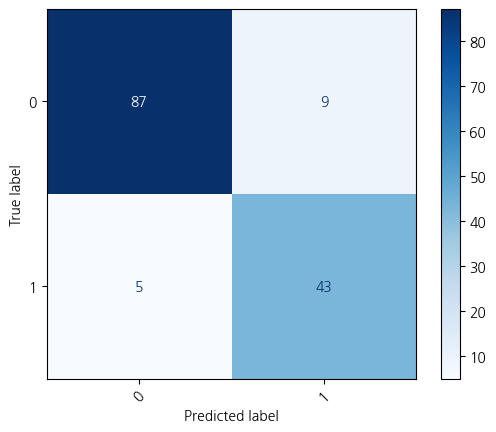

In [30]:


metrics.confusion_matrix(test_target, pred)
disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(test_target.unique())
)
disp.plot(
    cmap=plt.cm.Blues,
    xticks_rotation=45
)

plt.show()